# Simulation of Species Interacting in a Complex Ecosystem
##### <font color=gray>created by Pritom Mazumder | Dip Dutta | Kaushik Shankar Roy</font>

#### <font color=orange>Inspired from the Lotka–Volterra predator–prey model</font>

# Ecosystem Population Dynamics Simulation

This project simulates a multi-species ecosystem using differential equations inspired by Lotka–Volterra models.

Species included:
- Plants
- Herbivores
- Omnivores
- Carnivores
- Scavengers
- Saprophages
- Decomposers

The model analyzes predator–prey interactions and long-term ecosystem stability.

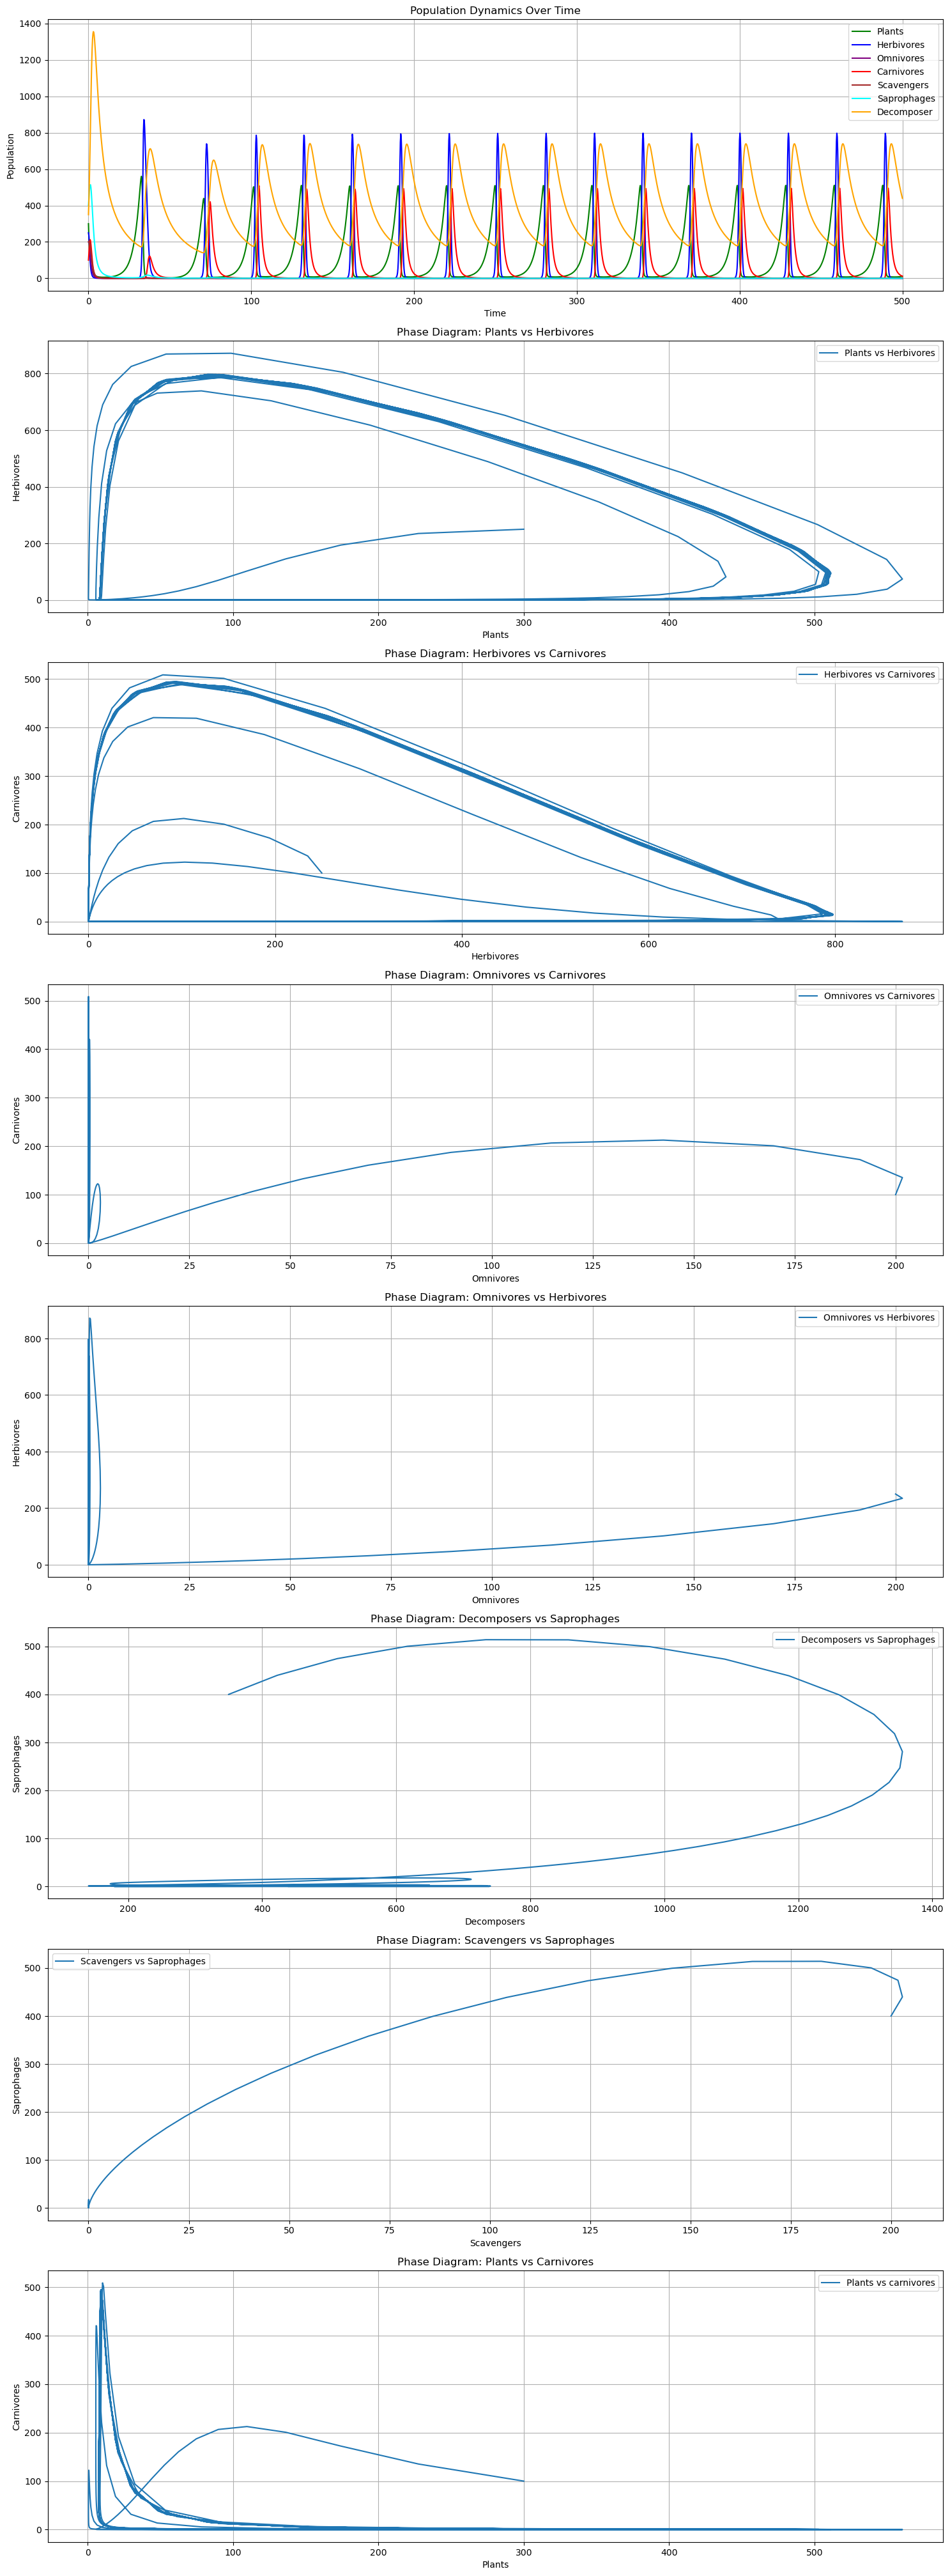

In [4]:
#Import Libraries
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

#Parameters
p = 0.4       # Plant growth rate
hp = 0.003    # Herbivores consume Plants as food
op = 0.0015   # Omnivores consume Plants as food
ph = 0.005    # Herbivores growth rate from Plants
oh = 0.0025   # Omnivores eat Herbivores rate
po = 0.001    # Omnivores growth rate from Plants
ho = 0.002    # Omnivores growth rate from Herbivores

sp = 0.0005 #   Plants eaten by saprophages
dp = 0.0006 #   Plants Eaten by Decompposer
hd = 0.0007 #   Herbivores eaten by decompposer

ch = 0.004    # Carnivore eats Herbivores rate
co = 0.002    # Carnivore eats Omnivores rate
hc = 0.005    # Carnivores growth rate from Herbivores
oc = 0.0025   # Carnivores growth rate from Omnivores
d = 0.0007    # Decomposition rate
pp = 0.0001   # Intraspecific competition among Plants
hh = 0.0002   # Intraspecific competition among Herbivores
oo = 0.0002   # Intraspecific competition among Omnivores
cc = 0.0002   # Intraspecific competition among Carnivores
ss = 0.0002   # Intraspecific competition among Scavengers
sasa = 0.0002 # Intraspecific competition among Saprophages
dd = 0.0002   # Intraspecific competition among Decomposer
sca = 0.001  # Scavengers growth rate
sap = 0.0006  # Saprophages growth rate

hsc = 0.0005  # Herbivores consumed by Scavengers rate
hsa = 0.0004  # Herbivores consumed by Saprophages rate
o_eating_c = 0.0003 # Omnivores consume Carnivores rate
sc_eating_o = 0.0004 # Scavengers consume Omnivores rate
sa_eating_o = 0.0004 # Saprophages consume Omnivores rate
d_eating_o = 0.0006 # Decomposer consumes Omnivores rate
c_eating_sc = 0.0006 # Carnivores consume Scavengers rate
sc_eating_c = 0.0004 # Scavengers consume Carnivores rate
sa_eating_c = 0.0005 # Saprophages consume Carnivores rate
d_eating_c = 0.0007 # Decomposer consumes Carnivores rate
sa_eating_sc = 0.0003 # Saprophages consume Scavengers rate
d_eating_sc = 0.0006 # Decomposer consumes Scavengers rate
d_eating_sa = 0.0004 # Decomposer consumes Saprophages rate
o_eating_sc = 0.0002 # Omnivores consume Scavengers rate

#Differential equations
def ecosystem(X, t):
    Plants, Herbivores, Omnivores, Carnivores, Scavengers, Saprophages, Decomposer = X

    d_Plants_dt = (p * Plants) - (hp * Herbivores * Plants) - (op * Omnivores * Plants) - (sp * Saprophages * Plants) - (dp * Decomposer * Plants) - (pp * Plants**2)
    
    d_Herbivores_dt = (ph * Plants * Herbivores) - (ch * Carnivores * Herbivores) - (oh * Omnivores * Herbivores) - (hsc * Herbivores * Scavengers) - (hsa * Herbivores * Saprophages ) - (hd * Herbivores * Decomposer) - (hh * Herbivores**2)
    
    d_Omnivores_dt = (po * Plants * Omnivores) + (ho * Herbivores * Omnivores) + (o_eating_c * Carnivores * Omnivores) - (co * Carnivores * Omnivores) - (sc_eating_o * Scavengers * Omnivores) - (sa_eating_o * Saprophages * Omnivores ) - (d_eating_o * Decomposer * Omnivores) - (oo * Omnivores**2)
    
    d_Carnivore_dt = (hc * Herbivores * Carnivores) + (oc * Omnivores * Carnivores) + (c_eating_sc * Carnivores * Scavengers) - (o_eating_c * Carnivores * Omnivores) - (sc_eating_c * Carnivores * Scavengers) - (sa_eating_c * Saprophages * Carnivores) - (d_eating_c * Decomposer * Carnivores)- (cc * Carnivores**2)
    
    d_Scavengers_dt = (sca * (Herbivores + Omnivores + Carnivores) * Scavengers) - (o_eating_sc * Omnivores * Scavengers) - (c_eating_sc * Carnivores * Scavengers) - (sa_eating_sc * Saprophages * Scavengers) - (d_eating_sc * Decomposer * Scavengers) - (ss * Scavengers**2)
    
    d_Saprophages_dt = (sap * (Plants + Herbivores + Omnivores + Carnivores + Scavengers) * Saprophages) - (d_eating_sa * Decomposer * Saprophages) - (sasa * Saprophages**2)
    
    d_Decomposer_dt = (d * (Herbivores + Omnivores + Carnivores + Scavengers + Saprophages) * Decomposer) - (dd * Decomposer**2)

    return [d_Plants_dt, d_Herbivores_dt, d_Omnivores_dt, d_Carnivore_dt, d_Scavengers_dt, d_Saprophages_dt, d_Decomposer_dt]

#Initials
X0 = [300, 250, 200, 100, 200, 400, 350]


t = np.linspace(0, 500, 2000)

sol = odeint(ecosystem, X0, t)
Plants, Herbivores, Omnivores, Carnivores, Scavengers, Saprophages, Decomposer = sol.T

#Plotting
plt.figure(figsize=(15, 45))

#Factors vs time
plt.subplot(9, 1,1)
plt.plot(t, Plants, 'green', label='Plants')
plt.plot(t, Herbivores, 'blue', label='Herbivores')
plt.plot(t, Omnivores, 'purple', label='Omnivores')
plt.plot(t, Carnivores, 'red', label='Carnivores')
plt.plot(t, Scavengers, 'brown', label='Scavengers')
plt.plot(t, Saprophages, 'cyan', label='Saprophages')
plt.plot(t, Decomposer, 'orange', label='Decomposer')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Population Dynamics Over Time')
plt.legend()
plt.grid()

#Plants vs Herbivores
plt.subplot(9, 1, 2)
plt.plot(Plants, Herbivores, label='Plants vs Herbivores')
plt.xlabel('Plants')
plt.ylabel('Herbivores')
plt.title('Phase Diagram: Plants vs Herbivores')
plt.legend()
plt.grid()

#Herbivores vs Carnivores
plt.subplot(9, 1,3)
plt.plot(Herbivores, Carnivores, label='Herbivores vs Carnivores')
plt.xlabel('Herbivores')
plt.ylabel('Carnivores')
plt.title('Phase Diagram: Herbivores vs Carnivores')
plt.legend()
plt.grid()

#Omnivores vs Carnivores
plt.subplot(9, 1,4)
plt.plot(Omnivores, Carnivores, label='Omnivores vs Carnivores')
plt.xlabel('Omnivores')
plt.ylabel('Carnivores')
plt.title('Phase Diagram: Omnivores vs Carnivores')
plt.legend()
plt.grid()

#Omnivores vs Herbivores
plt.subplot(9, 1, 5 )
plt.plot(Omnivores, Herbivores, label='Omnivores vs Herbivores')
plt.xlabel('Omnivores')
plt.ylabel('Herbivores')
plt.title('Phase Diagram: Omnivores vs Herbivores')
plt.legend()
plt.grid()

#Decomposers vs Saprophages
plt.subplot(9, 1,6)
plt.plot(Decomposer, Saprophages, label='Decomposers vs Saprophages')
plt.xlabel('Decomposers')
plt.ylabel('Saprophages')
plt.title('Phase Diagram: Decomposers vs Saprophages')
plt.legend()
plt.grid()

#Scavengers vs Saprophages
plt.subplot(9, 1,7)
plt.plot(Scavengers, Saprophages, label='Scavengers vs Saprophages')
plt.xlabel('Scavengers')
plt.ylabel('Saprophages')
plt.title('Phase Diagram: Scavengers vs Saprophages')
plt.legend()
plt.grid()

#Plants vs Carnivores
plt.subplot(9, 1,8)
plt.plot(Plants, Carnivores, label='Plants vs carnivores')
plt.xlabel('Plants')
plt.ylabel('Carnivores')
plt.title('Phase Diagram: Plants vs Carnivores')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()